# From TEI to Networks: People and Shared Contexts

This notebook shows a complete teaching workflow:

1. Retrieve TEI excerpts (printed pages) from a DTS endpoint.
2. Save TEI XML files locally for reproducibility.
3. Extract person mentions (label + identifier, e.g. GND) from each page.
4. Build a bipartite person-page network.
5. Project it to a one-mode person-person network.
6. Visualize both networks.

We use one volume of the Wölfflin edition:
- Collection: `https://example.org/dts/collections/hwgw/s01`
- Resource used for navigation/document calls: `https://example.org/dts/collections/hwgw/s01/ed`

## 1) Setup

Install dependencies (first line installs the DTS client from GitHub):

```bash
pip install https://github.com/distributed-text-services/validator/archive/refs/heads/main.zip
pip install requests beautifulsoup4 pandas networkx matplotlib lxml tqdm
```

In [43]:
# Import the libraries used throughout the notebook.
import json
from pathlib import Path
from typing import Dict, List, Optional
from urllib.parse import quote

import requests
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from tqdm.auto import tqdm
from ipysigma import Sigma
from dts_validator.client import DTS_API

# Define constants in one place so they are easy to update.
DTS_BASE = "https://rs4.ethz.ch/dts/"
COLLECTION_ID = "https://example.org/dts/collections/hwgw/s01"
RESOURCE_ID = "https://example.org/dts/collections/hwgw/s01/ed"
TREE_NAME = "published_page"

# Store downloaded TEI excerpts under the data folder.
DATA_DIR = Path("../../data")
TEI_DIR = DATA_DIR / "tei_hwgw_s01_pages"
TEI_DIR.mkdir(parents=True, exist_ok=True)

print(f"TEI data folder: {TEI_DIR.resolve()}")

TEI data folder: /Users/mromanel/Documents/UZH-SARI/UoTartu-NAH-2026/data/tei_hwgw_s01_pages


## 2) Retrieve TEI pages from DTS

We initialize a DTS client, call `navigation` to list printed pages, then call `document` for each page and save the TEI XML locally.

In [29]:
# Build a DTS client instance.
# Validation is disabled because some real-world DTS deployments can vary in minor ways.
dts_client = DTS_API(DTS_BASE, enable_validation=False)

# A helper function to request navigation data using plain HTTP.
# We use this explicit request so students can inspect the endpoint directly.
def get_navigation_json(resource_id: str, tree: str = TREE_NAME, down: int = -1) -> Dict:
    """Fetch navigation JSON that lists citable units (printed pages)."""
    params = {
        "resource": resource_id,
        "down": down,
        "tree": tree,
    }
    response = requests.get(f"{DTS_BASE}navigation/", params=params, timeout=60)
    response.raise_for_status()
    return response.json()

# A helper to extract page refs from DTS navigation members.
def collect_refs(navigation_json: Dict) -> List[str]:
    """Extract page references from navigation_json['members']."""
    refs: List[str] = []

    # In this DTS response, pages are listed directly in the top-level 'members' array.
    members = navigation_json.get("member", [])

    for member in members:
        if not isinstance(member, dict):
            continue

        # Each citable unit stores the page ref in 'identifier' (e.g. 's01-pg33').
        identifier = member.get("identifier")
        if isinstance(identifier, str) and identifier.strip():
            refs.append(identifier.strip())

    # Fallback: if 'members' is empty, also support legacy key 'ref'.
    if len(refs) == 0:
        for member in members:
            if isinstance(member, dict) and isinstance(member.get("identifier"), str):
                refs.append(member["identifier"].strip())

    # Remove duplicates while preserving order.
    refs_unique = list(dict.fromkeys(refs))
    return refs_unique

In [31]:
# Request the list of printed pages from the navigation endpoint.
nav_json = get_navigation_json(RESOURCE_ID)
page_refs = collect_refs(nav_json)

print(f"Number of refs discovered: {len(page_refs)}")
print("First refs:", page_refs[:10])

# If no refs are found, raise a clear error to avoid silent downstream failures.
if len(page_refs) == 0:
    raise ValueError("No page references found in navigation response.")

Number of refs discovered: 42
First refs: ['s01-pg33', 's01-pg34', 's01-pg35', 's01-pg36', 's01-pg37', 's01-pg38', 's01-pg39', 's01-pg40', 's01-pg41', 's01-pg42']


In [35]:
# A local helper that mimics dts_client.document() and adds support for the `tree` parameter.
def document_with_tree(
    resource: str,
    reference: Optional[str] = None,
    start: Optional[str] = None,
    end: Optional[str] = None,
    tree: Optional[str] = None,
):
    """Return (document_text, response) similarly to dts_client.document(), with optional `tree`."""
    # Build query parameters in the same spirit as DTS client document calls.
    params = {
        "resource": resource,
        "ref": reference,
        "start": start,
        "end": end,
        "tree": tree,
    }

    # Remove None values so the request only contains explicit parameters.
    params = {k: v for k, v in params.items() if v is not None}

    # Request the DTS document endpoint directly.
    response = requests.get(f"{DTS_BASE}document/", params=params, timeout=60)
    response.raise_for_status()

    # Keep the return signature compatible with dts_client.document().
    return response.text, response


# A small wrapper for readability in the download loop.
def fetch_tei_page(resource_id: str, ref: str, tree: str = TREE_NAME) -> str:
    """Fetch TEI XML for a given page reference."""
    document_text, _ = document_with_tree(resource=resource_id, reference=ref, tree=tree)
    return document_text


# Save all page TEI XML files locally so later steps can run offline.
for ref in tqdm(page_refs, desc="Downloading TEI pages"):
    xml_text = fetch_tei_page(RESOURCE_ID, ref)
    output_path = TEI_DIR / f"{ref}.xml"
    output_path.write_text(xml_text, encoding="utf-8")

print(f"Saved {len(page_refs)} TEI excerpts in {TEI_DIR}")

Saved 42 TEI excerpts in ../../data/tei_hwgw_s01_pages


## 3) Extract person mentions from TEI

For each page, we parse TEI XML and extract person mentions (`<persName>`), including:
- a human-readable label
- a disambiguating identifier (when present, often from `@ref`, potentially GND)

In [36]:
# Helper function to normalize person identifiers.
def normalize_person_identifier(raw_ref: Optional[str], fallback_label: str) -> str:
    """Return a stable person identifier from @ref (or fallback to label)."""
    # If no explicit identifier exists, create a local ID from the label.
    if raw_ref is None or str(raw_ref).strip() == "":
        safe_label = fallback_label.strip().lower().replace(" ", "_")
        return f"person::{safe_label}"

    # TEI @ref may contain compact IDs (e.g., gnd-118634496) or URI-like values.
    return raw_ref.strip()


# Helper function to parse one TEI page and extract person mentions.
def extract_person_mentions_from_tei(xml_text: str, page_ref: str) -> List[Dict]:
    """Extract person mentions from TEI XML for one page."""
    soup = BeautifulSoup(xml_text, "xml")
    mentions: List[Dict] = []

    # Primary pattern for this corpus: <rs type="person" ref="...">Name</rs>
    rs_person_nodes = soup.find_all("rs", attrs={"type": "person"})

    # Fallback pattern used in other TEI corpora.
    persname_nodes = soup.find_all("persName")

    # Combine both patterns; rs/type=person is first because it is corpus-specific.
    candidate_nodes = list(rs_person_nodes) + list(persname_nodes)

    for node in candidate_nodes:
        # Use text as display label and strip extra whitespace.
        label = " ".join(node.get_text(" ", strip=True).split())

        # Skip empty mentions to avoid malformed nodes in downstream graph logic.
        if label == "":
            continue

        # TEI may use @ref, @key, or @corresp for person IDs. We prioritize @ref.
        raw_id = node.get("ref") or node.get("key") or node.get("corresp")
        person_id = normalize_person_identifier(raw_id, label)

        mentions.append(
            {
                "page_ref": page_ref,
                "person_label": label,
                "person_id": person_id,
            }
        )

    # Remove duplicates (e.g., if the same mention is captured by both selectors).
    mentions_unique = list({(m["page_ref"], m["person_label"], m["person_id"]): m for m in mentions}.values())
    return mentions_unique

In [37]:
# Read all downloaded TEI files and extract mentions into one table.
all_mentions: List[Dict] = []

for tei_path in tqdm(sorted(TEI_DIR.glob("*.xml")), desc="Parsing TEI files"):
    # Recover page ref from filename (e.g., s01-pg73.xml -> s01-pg73).
    page_ref = tei_path.stem

    # Read XML text and extract mentions for this page.
    xml_text = tei_path.read_text(encoding="utf-8")
    page_mentions = extract_person_mentions_from_tei(xml_text, page_ref)
    all_mentions.extend(page_mentions)

# Build a DataFrame for easier analysis and network construction.
mentions_df = pd.DataFrame(all_mentions)

# Remove exact duplicates so repeated tags do not inflate edge counts.
mentions_df = mentions_df.drop_duplicates()

print(f"Total person-page mention records: {len(mentions_df)}")
mentions_df.head(10)

Parsing TEI files:   0%|          | 0/42 [00:00<?, ?it/s]

Total person-page mention records: 324


,page_ref,person_label,person_id
0,s01-pg33,Heinrich Wölfflin,gnd-118634496
1,s01-pg35,Benven. Cellini,gnd-118519875
2,s01-pg35,Dürer,gnd-11852786X
3,s01-pg35,Thausing,gnd-117300322
4,s01-pg35,Johann Wolfgang Goethe,gnd-118540238
5,s01-pg35,Albrecht Dürer,gnd-11852786X
6,s01-pg35,Goethes,gnd-118540238
7,s01-pg35,Goethe,gnd-118540238
8,s01-pg35,Empedokles,gnd-118530224
9,s01-pg35,Peter Schmidt,gnd-130247723


## 4) Build a person-page (bipartite) network

In this bipartite graph:
- one node set is people
- the other node set is pages
- edges represent mentions

In [41]:
# Encapsulate bipartite construction in a function to keep notebook cells simple.
def build_person_page_graph(mentions: pd.DataFrame) -> nx.Graph:
    """Create an undirected bipartite graph of people and pages."""
    graph = nx.Graph()

    # Add person nodes with a type attribute for filtering and styling.
    people = mentions[["person_id", "person_label"]].drop_duplicates()
    for _, row in people.iterrows():
        graph.add_node(
            row["person_id"],
            node_type="person",
            label=row["person_label"],
            bipartite=0,
        )

    # Add page nodes using the page reference as node ID and label.
    pages = mentions[["page_ref"]].drop_duplicates()
    for _, row in pages.iterrows():
        page_id = f"page::{row['page_ref']}"
        graph.add_node(
            page_id,
            node_type="page",
            label=row["page_ref"],
            bipartite=1,
        )

    # Add one edge per person-page mention relation.
    for _, row in mentions.iterrows():
        page_id = f"page::{row['page_ref']}"
        graph.add_edge(row["person_id"], page_id)

    return graph


G_bipartite = build_person_page_graph(mentions_df)
print(G_bipartite)

Graph with 152 nodes and 236 edges


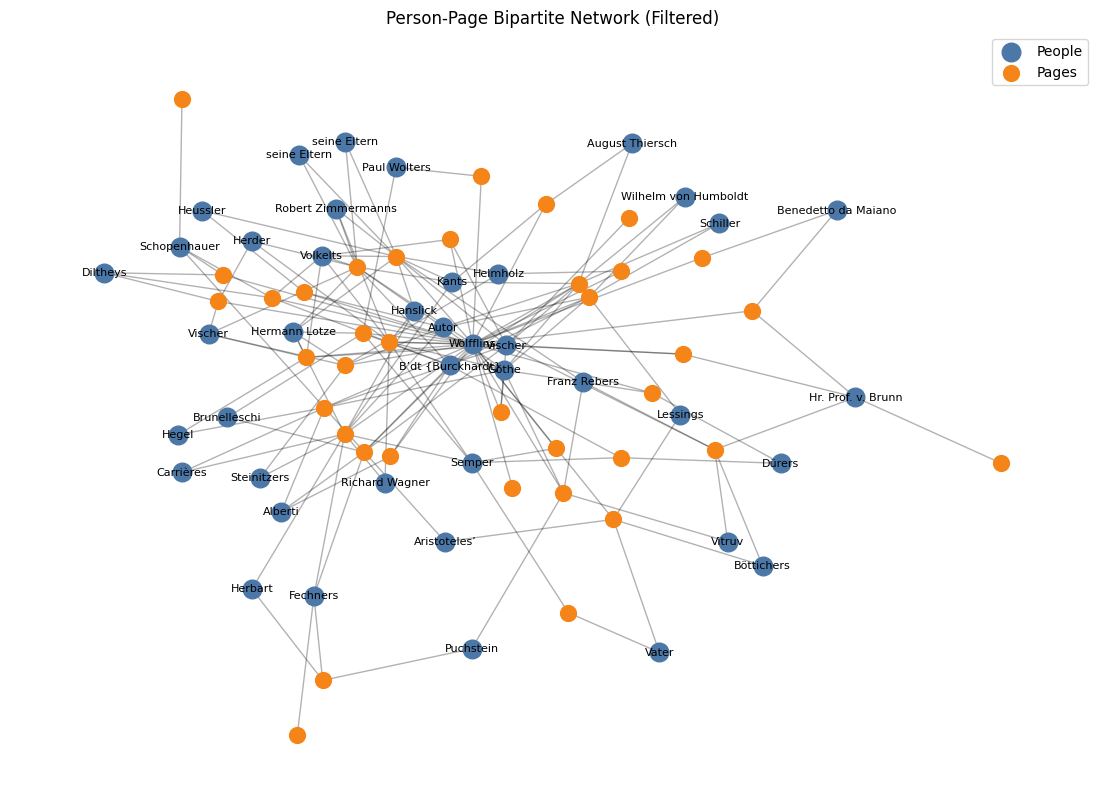

In [42]:
# Visualize a filtered bipartite graph for readability in class.
# We keep only people with degree >= 2 so isolated or singleton mentions do not dominate.
def plot_bipartite_graph(graph: nx.Graph, min_person_degree: int = 2):
    """Plot a small readable view of the bipartite graph."""
    # Select nodes to retain.
    nodes_to_keep = set()
    for node, attrs in graph.nodes(data=True):
        if attrs.get("node_type") == "person" and graph.degree(node) >= min_person_degree:
            nodes_to_keep.add(node)
            nodes_to_keep.update(graph.neighbors(node))

    subgraph = graph.subgraph(nodes_to_keep).copy()

    # Compute spring layout positions.
    pos = nx.spring_layout(subgraph, seed=42, k=0.35)

    # Split nodes by type to apply colors.
    person_nodes = [n for n, a in subgraph.nodes(data=True) if a.get("node_type") == "person"]
    page_nodes = [n for n, a in subgraph.nodes(data=True) if a.get("node_type") == "page"]

    plt.figure(figsize=(14, 10))
    nx.draw_networkx_nodes(subgraph, pos, nodelist=person_nodes, node_color="#4C78A8", node_size=180, label="People")
    nx.draw_networkx_nodes(subgraph, pos, nodelist=page_nodes, node_color="#F58518", node_size=130, label="Pages")
    nx.draw_networkx_edges(subgraph, pos, alpha=0.3)

    # Label only person nodes to keep the figure legible.
    person_labels = {n: subgraph.nodes[n].get("label", n) for n in person_nodes}
    nx.draw_networkx_labels(subgraph, pos, labels=person_labels, font_size=8)

    plt.title("Person-Page Bipartite Network (Filtered)")
    plt.legend()
    plt.axis("off")
    plt.show()


plot_bipartite_graph(G_bipartite, min_person_degree=2)

In [49]:
# Interactive network visualization with ipysigma (person-page bipartite graph).
# We keep only people with at least two page mentions to improve readability.
MIN_PERSON_DEGREE_BIPARTITE = 0

# Select person nodes that pass the degree threshold.
person_nodes_to_keep = {
    n
    for n, attrs in G_bipartite.nodes(data=True)
    if attrs.get("node_type") == "person" and G_bipartite.degree(n) >= MIN_PERSON_DEGREE_BIPARTITE
}

# Include all linked pages so context is preserved.
page_neighbors_to_keep = set()
for person_node in person_nodes_to_keep:
    page_neighbors_to_keep.update(G_bipartite.neighbors(person_node))

nodes_to_plot = person_nodes_to_keep | page_neighbors_to_keep
G_bip_sigma = G_bipartite.subgraph(nodes_to_plot).copy()

# Add styling attributes expected by Sigma.
for node, attrs in G_bip_sigma.nodes(data=True):
    attrs["viz_category"] = attrs.get("node_type", "unknown")

# Recompute degree in the filtered graph so node sizes match what is shown.
nx.set_node_attributes(G_bip_sigma, dict(G_bip_sigma.degree()), "degree")

n_people = sum(1 for _, a in G_bip_sigma.nodes(data=True) if a.get("node_type") == "person")
n_pages = sum(1 for _, a in G_bip_sigma.nodes(data=True) if a.get("node_type") == "page")
print(
    f"Interactive bipartite graph: {n_people:,} people, {n_pages:,} pages, "
    f"{G_bip_sigma.number_of_edges():,} edges."
)

# Render the interactive bipartite network.
Sigma(
    G_bip_sigma,
    node_color="viz_category",
    node_size="degree",
    node_label="label",
    default_edge_type="line",
    start_layout=True,
    clickable_edges=False,
    hide_info_panel=False,
)

Interactive bipartite graph: 114 people, 38 pages, 236 edges.


Sigma(nx.Graph with 152 nodes and 236 edges)

## 5) Project to a person-person network

Two people are connected if they are mentioned in the same page.

Edge weight = number of shared pages.

In [50]:
# Build the one-mode projection using NetworkX bipartite utilities.
def project_to_person_network(graph_bipartite: nx.Graph) -> nx.Graph:
    """Project person-page bipartite graph onto a person-person graph."""
    # Identify the person node set that should be projected.
    person_nodes = {
        n for n, attrs in graph_bipartite.nodes(data=True)
        if attrs.get("node_type") == "person"
    }

    # Weighted projection counts shared neighbors (shared pages) as edge weights.
    projected = nx.bipartite.weighted_projected_graph(graph_bipartite, person_nodes)

    # Preserve person labels from the bipartite graph for plotting.
    for node in projected.nodes:
        projected.nodes[node]["label"] = graph_bipartite.nodes[node].get("label", node)

    return projected


G_people = project_to_person_network(G_bipartite)
print(G_people)

# Inspect the strongest co-mention edges.
top_edges = sorted(G_people.edges(data=True), key=lambda x: x[2].get("weight", 0), reverse=True)
print("Top weighted edges:")
for u, v, attrs in top_edges[:10]:
    print(f"- {G_people.nodes[u]['label']} -- {G_people.nodes[v]['label']} (weight={attrs.get('weight', 1)})")

Graph with 114 nodes and 856 edges
Top weighted edges:
- Wölfflins -- Vischer (weight=9)
- Göthe -- Wölfflins (weight=8)
- B’dt {Burckhardt} -- Wölfflins (weight=7)
- Wölfflins -- Volkelts (weight=6)
- Wölfflins -- Hermann Lotze (weight=6)
- Autor -- Wölfflins (weight=5)
- Kants -- Wölfflins (weight=5)
- Göthe -- Vischer (weight=4)
- Wölfflins -- Vischer (weight=4)
- Wölfflins -- Semper (weight=4)


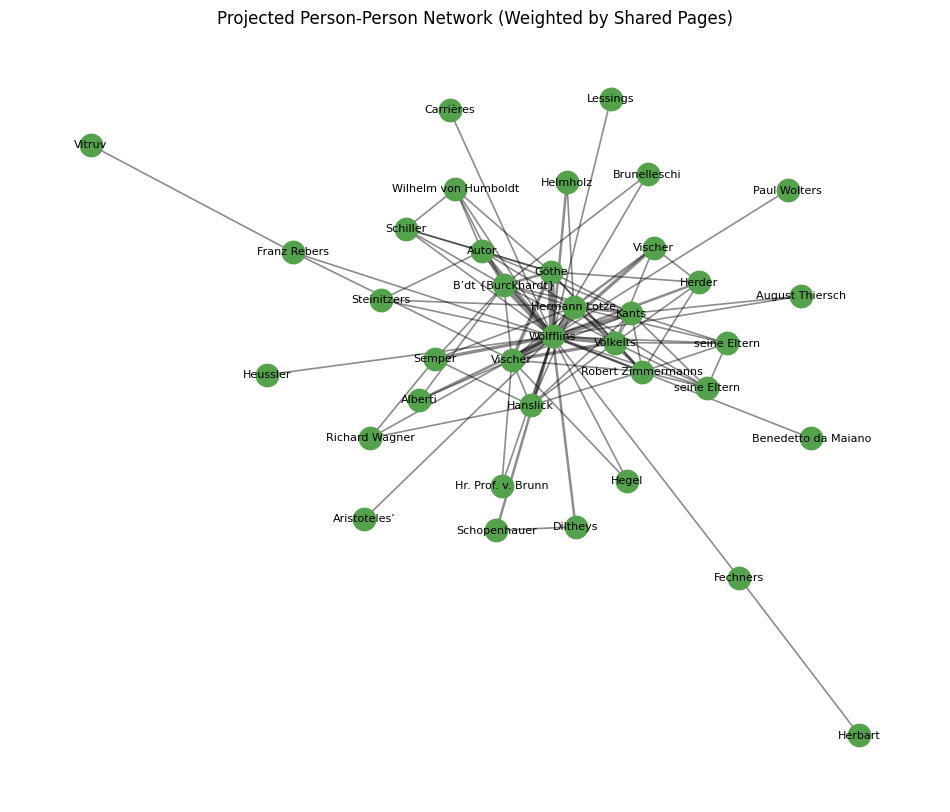

In [51]:
# Plot the projected person-person network.
def plot_person_projection(graph_people: nx.Graph, min_edge_weight: int = 2):
    """Plot a readable person-person projection with weighted edges."""
    # Keep only stronger co-mention edges for visual clarity.
    strong_edges = [
        (u, v, d)
        for u, v, d in graph_people.edges(data=True)
        if d.get("weight", 1) >= min_edge_weight
    ]

    # Build a subgraph from selected edges.
    subgraph = nx.Graph()
    subgraph.add_edges_from(strong_edges)

    # Carry node labels to the filtered graph.
    for n in subgraph.nodes:
        subgraph.nodes[n]["label"] = graph_people.nodes[n].get("label", n)

    # If no strong edges survive, notify students clearly.
    if subgraph.number_of_edges() == 0:
        print("No edges satisfy the selected minimum weight. Lower min_edge_weight and rerun.")
        return

    pos = nx.spring_layout(subgraph, seed=42, k=0.5)
    edge_widths = [subgraph[u][v].get("weight", 1) * 0.6 for u, v in subgraph.edges()]

    plt.figure(figsize=(12, 10))
    nx.draw_networkx_nodes(subgraph, pos, node_color="#54A24B", node_size=260)
    nx.draw_networkx_edges(subgraph, pos, width=edge_widths, alpha=0.45)

    labels = {n: subgraph.nodes[n].get("label", n) for n in subgraph.nodes}
    nx.draw_networkx_labels(subgraph, pos, labels=labels, font_size=8)

    plt.title("Projected Person-Person Network (Weighted by Shared Pages)")
    plt.axis("off")
    plt.show()


plot_person_projection(G_people, min_edge_weight=2)

In [ ]:
# Optional variant: interactive projection where edge thickness encodes edge weight.
# Use the scaled edge-size attribute for stronger visual contrast.
Sigma(
    G_people_sigma,
    node_color="viz_category",
    node_size="degree",
    node_label="label",
    edge_size="edge_size_scaled",
    default_edge_type="line",
    start_layout=True,
    clickable_edges=False,
    hide_info_panel=False,
)

In [72]:
# Interactive network visualization with ipysigma (person-person projection).
# We filter weak ties to keep the graph readable in an interactive widget.
MIN_WEIGHT_FOR_INTERACTIVE = 2

# Build a filtered graph containing only edges above the selected co-mention threshold.
G_people_sigma = nx.Graph(
    (u, v, d)
    for u, v, d in G_people.edges(data=True)
    if d.get("weight", 1) >= MIN_WEIGHT_FOR_INTERACTIVE
)

# Add node attributes needed for styling and tooltips in Sigma.
for node in G_people_sigma.nodes:
    G_people_sigma.nodes[node]["label"] = G_people.nodes[node].get("label", node)
    G_people_sigma.nodes[node]["viz_category"] = "person"

# Store degree as a numeric attribute so node size encodes connectivity.
nx.set_node_attributes(G_people_sigma, dict(G_people_sigma.degree()), "degree")

# Increase visual contrast by mapping raw weights to a wider edge-size range.
#for _, _, attrs in G_people_sigma.edges(data=True):
#    w = float(attrs.get("weight", 1))
#    attrs["edge_size_scaled"] = 1.0 + 2.5 * w

print(
    f"Interactive graph: {G_people_sigma.number_of_nodes():,} nodes, "
    f"{G_people_sigma.number_of_edges():,} edges (weight >= {MIN_WEIGHT_FOR_INTERACTIVE})."
)

# Render the interactive Sigma view directly in the notebook.
Sigma(
    G_people_sigma,
    node_color="viz_category",
    node_size="degree",
    node_label="label",
    edge_size="weight",
    edge_size_range=(1, 20),
    #edge_size_scale="log",
    default_edge_type="rectangle",
    start_layout=True,
    #clickable_edges=True,
    hide_info_panel=False,
)

Interactive graph: 37 nodes, 102 edges (weight >= 2).


Sigma(nx.Graph with 37 nodes and 102 edges)

In [65]:
# Inspect minimum and maximum edge weight in the interactive person-person graph.
if G_people_sigma.number_of_edges() == 0:
    print("The graph has no edges after filtering, so min/max weight cannot be computed.")
else:
    # Collect edges and weights once for reuse.
    weighted_edges = [
        (u, v, attrs.get("weight", 1))
        for u, v, attrs in G_people_sigma.edges(data=True)
    ]

    min_w = min(w for _, _, w in weighted_edges)
    max_w = max(w for _, _, w in weighted_edges)

    print(f"Min edge weight: {min_w}")
    print(f"Max edge weight: {max_w}")

    # Print all edges that match the min and max weights, including node labels.
    min_edges = [(u, v) for u, v, w in weighted_edges if w == min_w]
    max_edges = [(u, v) for u, v, w in weighted_edges if w == max_w]

    print("\nEdges with MIN weight:")
    for u, v in min_edges:
        u_label = G_people_sigma.nodes[u].get("label", u)
        v_label = G_people_sigma.nodes[v].get("label", v)
        print(f"- {u_label} -- {v_label}")

    print("\nEdges with MAX weight:")
    for u, v in max_edges:
        u_label = G_people_sigma.nodes[u].get("label", u)
        v_label = G_people_sigma.nodes[v].get("label", v)
        print(f"- {u_label} -- {v_label}")

Min edge weight: 2
Max edge weight: 9

Edges with MIN weight:
- Autor -- Kants
- Autor -- Steinitzers
- Autor -- Wilhelm von Humboldt
- Autor -- Hermann Lotze
- Autor -- Göthe
- Autor -- Schiller
- Autor -- B’dt {Burckhardt}
- Kants -- Göthe
- Kants -- B’dt {Burckhardt}
- Kants -- Hanslick
- Kants -- seine Eltern
- Kants -- Volkelts
- Kants -- seine Eltern
- Kants -- Robert Zimmermanns
- Kants -- August Thiersch
- Kants -- Vischer
- Steinitzers -- Hermann Lotze
- Steinitzers -- Wölfflins
- Wilhelm von Humboldt -- Göthe
- Wilhelm von Humboldt -- B’dt {Burckhardt}
- Wilhelm von Humboldt -- Wölfflins
- Wilhelm von Humboldt -- Schiller
- Wölfflins -- Benedetto da Maiano
- Wölfflins -- Carrières
- Wölfflins -- Paul Wolters
- Wölfflins -- Hr. Prof. v. Brunn
- Wölfflins -- Brunelleschi
- Wölfflins -- seine Eltern
- Wölfflins -- Franz Rebers
- Wölfflins -- Schiller
- Wölfflins -- Richard Wagner
- Wölfflins -- Aristoteles’
- Wölfflins -- Heussler
- Wölfflins -- seine Eltern
- Wölfflins -- Lessi

## 6) Save outputs

We save both graph variants and the extracted mention table so the workflow is reusable in later sessions.

In [73]:
# Define output files under the data folder.
mentions_path = DATA_DIR / "tei_person_page_mentions.csv"
bipartite_path = DATA_DIR / "tei_person_page_bipartite.gexf"
projected_path = DATA_DIR / "tei_person_person_projection.gexf"

# Save tabular and graph outputs.
mentions_df.to_csv(mentions_path, index=False)
nx.write_gexf(G_bipartite, bipartite_path)
nx.write_gexf(G_people, projected_path)

print("Saved files:")
print(f"- {mentions_path.resolve()}")
print(f"- {bipartite_path.resolve()}")
print(f"- {projected_path.resolve()}")

Saved files:
- /Users/mromanel/Documents/UZH-SARI/UoTartu-NAH-2026/data/tei_person_page_mentions.csv
- /Users/mromanel/Documents/UZH-SARI/UoTartu-NAH-2026/data/tei_person_page_bipartite.gexf
- /Users/mromanel/Documents/UZH-SARI/UoTartu-NAH-2026/data/tei_person_person_projection.gexf
